In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

Select features

In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

In [5]:
centers = kmeans.cluster_centers_

centers_df = pd.DataFrame(centers, columns=['Income', 'Spending'])
centers_df['Cluster'] = centers_df.index

print("Cluster Centers:")
print(centers_df)

Cluster Centers:
      Income   Spending  Cluster
0  55.296296  49.518519        0
1  86.538462  82.128205        1
2  25.727273  79.363636        2
3  88.200000  17.114286        3
4  26.304348  20.913043        4


In [6]:
# Function to assign business labels
def label_cluster(row):
    income = row['Income']
    spending = row['Spending']
    
    if income > 70 and spending > 60:
        return 'High Value'
    elif income > 70 and spending <= 60:
        return 'Potential Growth'
    elif income <= 40 and spending > 60:
        return 'Impulsive'
    elif income <= 40 and spending <= 40:
        return 'Low Value'
    else:
        return 'Average'

# Apply labels to cluster centers
centers_df['Segment'] = centers_df.apply(label_cluster, axis=1)

# Map cluster number to segment name
cluster_label_map = dict(zip(centers_df['Cluster'], centers_df['Segment']))

# Assign segment names to original data
df['Segment'] = df['Cluster'].map(cluster_label_map)

# Show sample
print(df[['Annual Income (k$)', 'Spending Score (1-100)', 'Segment']].head())

   Annual Income (k$)  Spending Score (1-100)    Segment
0                  15                      39  Low Value
1                  15                      81  Impulsive
2                  16                       6  Low Value
3                  16                      77  Impulsive
4                  17                      40  Low Value


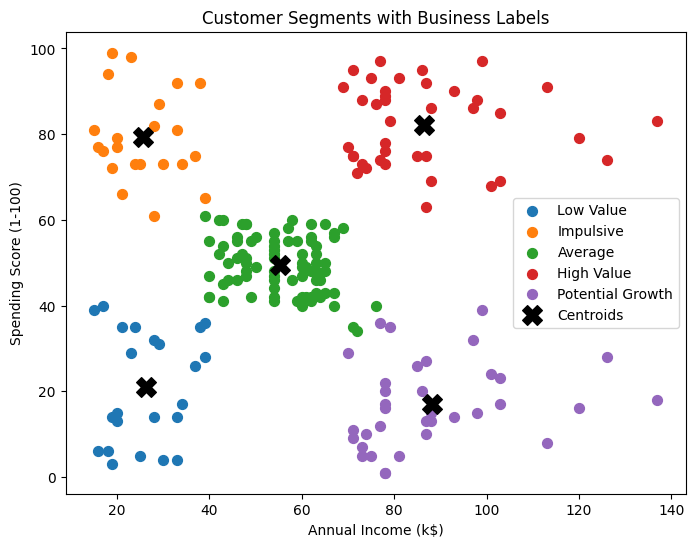

In [7]:
plt.figure(figsize=(8,6))

for segment in df['Segment'].unique():
    subset = df[df['Segment'] == segment]
    plt.scatter(subset['Annual Income (k$)'],
                subset['Spending Score (1-100)'],
                label=segment,
                s=50)

# Plot centroids
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments with Business Labels')
plt.legend()
plt.show()

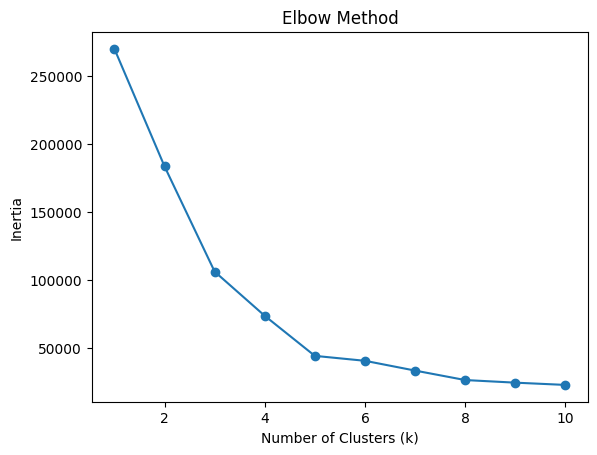

In [8]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()